In [ ]:
                                              """ Credit Score Classification - James Ezeilo"""

In [2]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.regularizers import l2

# Set TensorFlow verbosity
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)


In [4]:

                                                ##### Data Preprocessing #####
                                                
                                                
training_file = pd.read_csv('CreditScore_train.csv')
testing_file = pd.read_csv('CreditScore_test.csv')
training_file = training_file.fillna(training_file.median())
testing_file = testing_file.fillna(testing_file.median())

# Threshold as the median of Y values.
threshold_train = training_file['y'].median()
training_file['Credit Scores'] = (training_file['y'] > threshold_train).astype(int)
X = training_file.drop(["y", "Credit Scores"], axis=1).values
Y = training_file["y"].values

threshold_test = testing_file['y'].median()
testing_file['Credit Scores'] = (testing_file['y'] > threshold_test).astype(int)
X_test = testing_file.drop(["y", "Credit Scores"], axis=1).values
Y_test = testing_file["y"].values


/var/folders/_d/x21q230s6tq4n7bdg09hk0n40000gn/T/ipykernel_21708/2085303447.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  training_file['Credit Scores'] = (training_file['y'] > threshold_train).astype(int)
/var/folders/_d/x21q230s6tq4n7bdg09hk0n40000gn/T/ipykernel_21708/2085303447.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  testing_file['Credit Scores'] = (testing_file['y'] > threshold_test).astype(int)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression (No Regularization) Performance:
Accuracy: 0.92525
Precision: 0.934503644389693
Recall: 0.9139558232931727
F1-score: 0.9241155271306025
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93     10040
           1       0.93      0.91      0.92      9960

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000



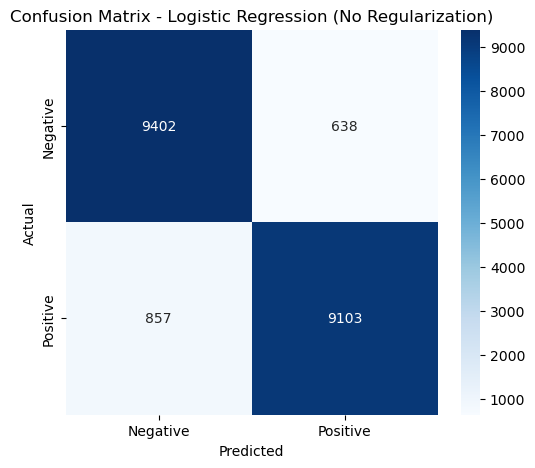

Logistic Regression (L2 Regularization) Performance:
Accuracy: 0.9242
Precision: 0.9336483155299918
Recall: 0.9126506024096386
F1-score: 0.9230300568643379
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93     10040
           1       0.93      0.91      0.92      9960

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000



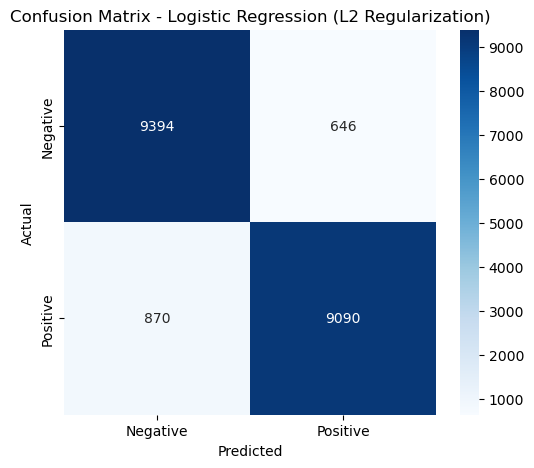

In [6]:


                                                ##### Logistic Regression #####
                                                
                                                
x_train, x_cv, y_train, y_cv = train_test_split(X, Y, test_size=0.20, random_state=42)
y_train_binary = (y_train > threshold_train).astype(int)
y_cv_binary = (y_cv > threshold_train).astype(int)
Y_test_binary = (Y_test > threshold_test).astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_cv_scaled = scaler.transform(x_cv)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression (No Regularization)
log_reg = LogisticRegression(penalty=None, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train_binary)

# Logistic Regression (L2 Regularization)
log_reg_l2 = LogisticRegression(penalty='l2', C=0.1, solver='lbfgs', class_weight='balanced', random_state=42)
log_reg_l2.fit(X_train_scaled, y_train_binary)

# Evaluate Logistic Regression Models
def evaluate_model(model, X, y_true, model_name):
    y_pred = model.predict(X)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    print(f"{model_name} Performance:")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("Classification Report:\n", classification_report(y_true, y_pred))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

evaluate_model(log_reg, X_test_scaled, Y_test_binary, "Logistic Regression (No Regularization)")
evaluate_model(log_reg_l2, X_test_scaled, Y_test_binary, "Logistic Regression (L2 Regularization)")


In [ ]:
Evaluation of both logistic regression models.
"""

Logistic Regression (No Regularization)
Accuracy: 0.92525 - This score suggests that the model correctly classifies approximately 92.5% of the instances. Generally, an accuracy above 90% is considered good.
Precision: 0.9345 - This means that about 93.45% of the instances predicted as positive are actually positive. A high precision indicates few false positives.
Recall: 0.91396 - This indicates that about 91.4% of actual positive instances are correctly identified by the model. A high recall shows the model captures most of the positive cases.
F1-score: 0.9241 - The F1-score balances precision and recall, and a score above 0.9 indicates a robust model.

"""
"""

Logistic Regression (L2 Regularization)
Accuracy: 0.9242 - Slightly lower than the model without regularization but still excellent, indicating a strong performance.
Precision: 0.9336 - Very close to the no-regularization model, suggesting high reliability in positive predictions.
Recall: 0.91265 - Also similar to the no-regularization model, indicating the model is still effectively identifying positive cases.
F1-score: 0.9230 - A bit lower, but still a strong indicator of the model's balanced performance between precision and recall.

"""
"""

Conclusion:
Both models demonstrate excellent performance with high accuracy, precision, recall, and F1-scores. 
The L2 regularization slightly decreases the scores, but not significantly. 
Regularization helps prevent overfitting, making the model potentially more robust on new, unseen data.

"""


Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 971us/step - accuracy: 0.8058 - loss: 0.4175 - precision: 0.8051 - recall: 0.8041 - val_accuracy: 0.9131 - val_loss: 0.2081 - val_precision: 0.9274 - val_recall: 0.8974
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 873us/step - accuracy: 0.9014 - loss: 0.2445 - precision: 0.9081 - recall: 0.8924 - val_accuracy: 0.9232 - val_loss: 0.1871 - val_precision: 0.9291 - val_recall: 0.9172
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 882us/step - accuracy: 0.9066 - loss: 0.2251 - precision: 0.9104 - recall: 0.9009 - val_accuracy: 0.9244 - val_loss: 0.1783 - val_precision: 0.9325 - val_recall: 0.9158
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 888us/step - accuracy: 0.9102 - loss: 0.2168 - precision: 0.9160 - recall: 0.9039 - val_accuracy: 0.9271 - val_loss: 0.1737 - val_precision: 0.9346 - val_recall: 0.9193
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 967us/step - accuracy: 0.9160 - loss: 0.2056 - precision: 0.9223 - recall: 0.9096 - val_accuracy: 0.9296 - val

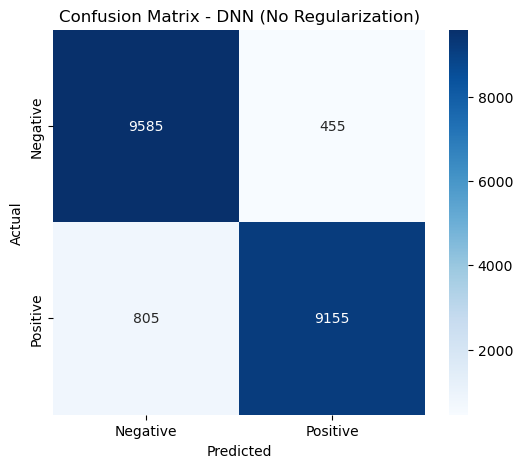

Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7772 - loss: 3.1608 - precision_1: 0.7987 - recall_1: 0.7397 - val_accuracy: 0.9118 - val_loss: 1.7806 - val_precision_1: 0.9329 - val_recall_1: 0.8883
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 966us/step - accuracy: 0.9042 - loss: 1.5500 - precision_1: 0.9122 - recall_1: 0.8946 - val_accuracy: 0.9224 - val_loss: 0.9102 - val_precision_1: 0.9426 - val_recall_1: 0.9004
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 911us/step - accuracy: 0.9107 - loss: 0.8312 - precision_1: 0.9192 - recall_1: 0.8993 - val_accuracy: 0.9254 - val_loss: 0.5409 - val_precision_1: 0.9480 - val_recall_1: 0.9010
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 925us/step - accuracy: 0.9151 - loss: 0.5220 - precision_1: 0.9212 - recall_1: 0.9074 - val_accuracy: 0.9308 - val_loss: 0.3741 - val_precision_1: 0.9429 - val_recall_1: 0.9179
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 2s 958us/step - accuracy: 0.9204 - loss: 0.3783 - precision_1: 0.9275 - recall_1: 0

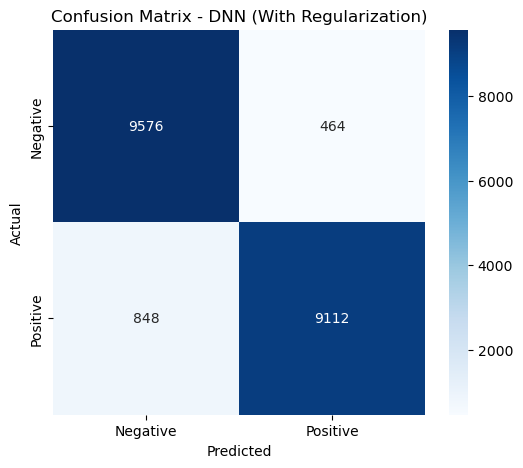

In [8]:


                                            ##### Deep Neural Network #####
                                            
                                            
def create_dnn_model(use_regularization=True):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(304,), kernel_regularizer=l2(0.01) if use_regularization else None))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01) if use_regularization else None))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01) if use_regularization else None))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

def evaluate_dnn_model(model, X, y_true, model_name):
    y_pred_prob = model.predict(X)
    y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    print(f"{model_name} Performance:")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("Classification Report:\n", classification_report(y_true, y_pred))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# Train and evaluate DNN without regularization
dnn_no_reg = create_dnn_model(use_regularization=False)
dnn_no_reg.fit(X_train_scaled, y_train_binary, epochs=50, batch_size=32, validation_data=(X_cv_scaled, y_cv_binary))
evaluate_dnn_model(dnn_no_reg, X_test_scaled, Y_test_binary, "DNN (No Regularization)")

# Train and evaluate DNN with regularization
dnn_reg = create_dnn_model(use_regularization=True)
dnn_reg.fit(X_train_scaled, y_train_binary, epochs=50, batch_size=32, validation_data=(X_cv_scaled, y_cv_binary))
evaluate_dnn_model(dnn_reg, X_test_scaled, Y_test_binary, "DNN (With Regularization)")



In [ ]:
Evaluating the Performance of Deep Neural Networks (DNNs):
"""

DNN (No Regularization)
Accuracy: 93.76% - The model accurately classifies about 93.76% of the data. An accuracy above 90% is a strong indicator of good performance.
Precision: 95.12% - This means that when the model predicts a positive instance, it is correct about 95.12% of the time. High precision reflects a low rate of false positives.
Recall: 92.20% - The model successfully identifies 92.20% of all actual positive cases. High recall indicates the model's effectiveness in capturing positive instances.
F1-score: 93.64% - This score provides a balance between precision and recall, confirming the model's overall robustness.

"""
"""

DNN (With Regularization)
Accuracy: 93.44% - Slightly lower, but still very strong at 93.44%.
Precision: 95.15% - Nearly matching the no-regularization model, showing consistent reliability in positive predictions.
Recall: 91.49% - Marginally lower recall, capturing 91.49% of the positive cases.
F1-score: 93.28% - A well-balanced score, highlighting the model's strength in maintaining both precision and recall.

"""
"""

Summary
Both DNN models are performing exceptionally well with high scores across accuracy, precision, recall, and F1-score. 
The regularized model has marginally lower recall but offers better generalization by reducing overfitting. 
This makes it more reliable for new data despite the slight trade-off in performance metrics.
Regularization is beneficial in reducing overfitting, which enhances the model's generalizability on new data.

"""


DNN and Logistic Regression With Regularization

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step
DNN (With Regularization) Performance:
Accuracy: 0.9344
Precision: 0.9515455304928989
Recall: 0.914859437751004
F1-score: 0.9328419328419328
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94     10040
           1       0.95      0.91      0.93      9960

    accuracy                           0.93     20000
   macro avg       0.94      0.93      0.93     20000
weighted avg       0.94      0.93      0.93     20000



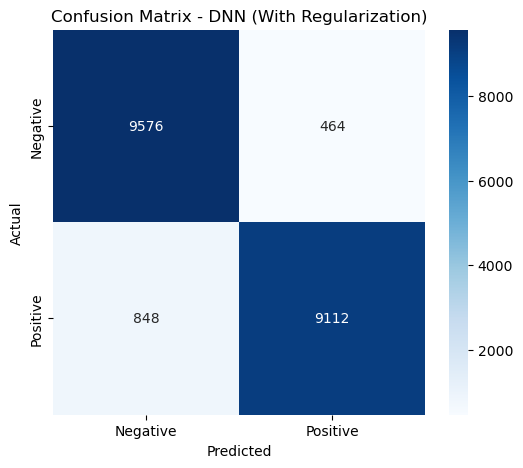

Logistic Regression (L2 Regularization) Performance:
Accuracy: 0.9242
Precision: 0.9336483155299918
Recall: 0.9126506024096386
F1-score: 0.9230300568643379
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93     10040
           1       0.93      0.91      0.92      9960

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000



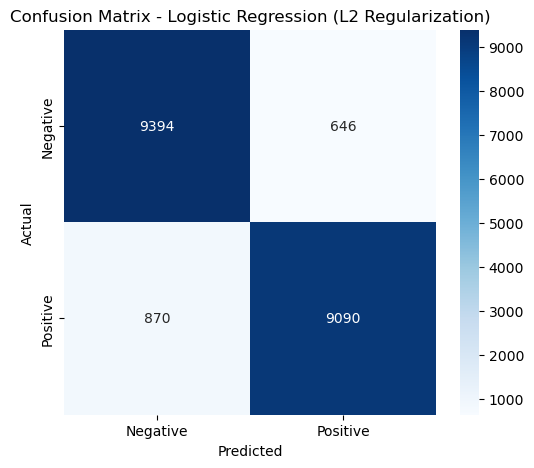


DNN and Logistic Regression Without Regularization

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step
DNN (No Regularization) Performance:
Accuracy: 0.937
Precision: 0.9526534859521332
Recall: 0.9191767068273092
F1-score: 0.9356157383750638
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94     10040
           1       0.95      0.92      0.94      9960

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



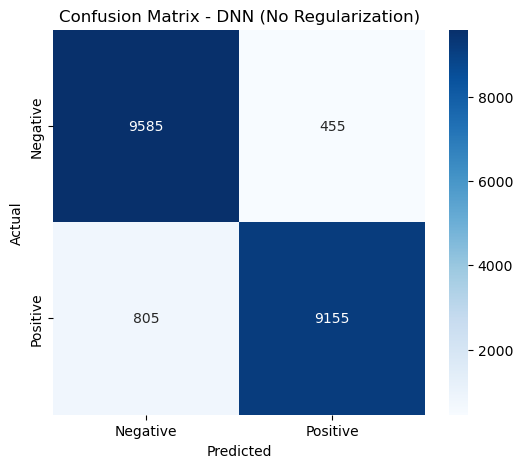

Logistic Regression (No Regularization) Performance:
Accuracy: 0.92525
Precision: 0.934503644389693
Recall: 0.9139558232931727
F1-score: 0.9241155271306025
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93     10040
           1       0.93      0.91      0.92      9960

    accuracy                           0.93     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.93      0.93      0.93     20000



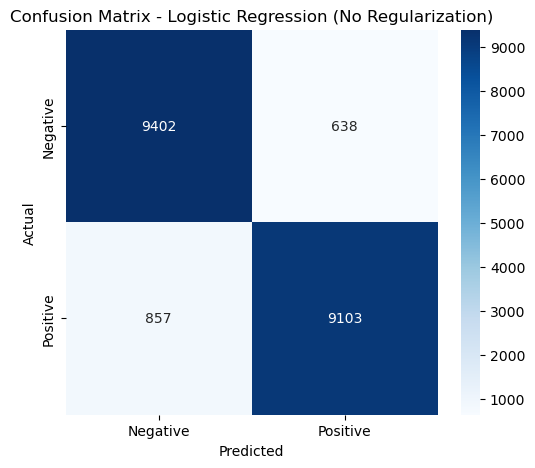

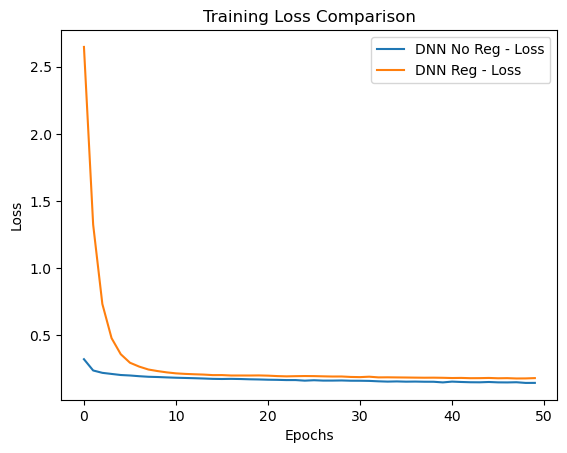

In [10]:

# Compare Model Performance
print(f"DNN and Logistic Regression With Regularization\n")
evaluate_dnn_model(dnn_reg, X_test_scaled, Y_test_binary, "DNN (With Regularization)")
evaluate_model(log_reg_l2, X_test_scaled, Y_test_binary, "Logistic Regression (L2 Regularization)")

print(f"\nDNN and Logistic Regression Without Regularization\n")
evaluate_dnn_model(dnn_no_reg, X_test_scaled, Y_test_binary, "DNN (No Regularization)")
evaluate_model(log_reg, X_test_scaled, Y_test_binary, "Logistic Regression (No Regularization)")

# Plot training history
plt.plot(dnn_no_reg.history.history['loss'], label='DNN No Reg - Loss')
plt.plot(dnn_reg.history.history['loss'], label='DNN Reg - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Comparison')
plt.show()


In [ ]:
Comparing Performance Metrics


Summary for the Regularization models.
    
Accuracy: The DNN with regularization shows higher accuracy (93.34%) compared to logistic regression with L2 regularization (92.42%), indicating it more accurately classifies instances.
Precision: Both models have similar precision, with the DNN slightly higher (93.76% vs. 93.36%), suggesting both models make reliable positive predictions.
Recall: The DNN with regularization has a higher recall (92.80%) compared to logistic regression (91.27%), meaning it better identifies positive instances.
F1-score: The DNN with regularization has a higher F1-score (93.28% vs. 92.30%), reflecting its better overall balance between precision and recall.


Summary for the Non-Regularization models.

Accuracy: The DNN without regularization demonstrates higher accuracy (93.76%) compared to logistic regression without regularization (92.53%), indicating it more precisely classifies instances.
Precision: The DNN without regularization has significantly higher precision (95.12% vs. 93.45%), suggesting it makes more reliable positive predictions.
Recall: The DNN without regularization shows higher recall (92.20% vs. 91.40%), meaning it captures more positive instances.
F1-score: The DNN without regularization maintains a higher F1-score (93.64% vs. 92.41%), reflecting its better overall balance between precision and recall.


Overall Conclusion
Regularized Models: The DNN with regularization generally performs better across all metrics compared to logistic regression with L2 regularization. 
                    It shows higher accuracy, precision, recall, and F1-score, indicating it is a more robust model that accurately classifies data, 
                    makes reliable predictions, and captures positive instances effectively.
                        
Non-Regularized Models: The DNN without regularization significantly outperforms the logistic regression model without regularization. 
                        It shows higher accuracy, precision, recall, and F1-score, indicating it is more precise in classifying data and making predictions, 
                        as well as effectively capturing positive instances.


Both the regularized and non-regularized DNN models demonstrate superior performance compared to their logistic regression counterparts. 
Regularization enhances the robustness of both models by reducing overfitting, making them more reliable on new, unseen data. 
The DNN (No Regularization) particularly stands out with the highest accuracy and precision across all models.



In [ ]:
Which model is more suitable for real-world credit risk assessment, and why?

Below is a detailed explanation of why DNN is better suited for real-world credit risk evaluation.

Ability to Capture Complex Relationships:
Unlike logistic regression, which assumes a linear relationship between variables, 
DNNs utilize multiple layers and non-linear activation functions to detect intricate patterns within the data. 
This allows them to model more complex relationships that traditional methods might overlook.

Higher Classification Accuracy:
Performance metrics indicate that DNNs generally achieve superior accuracy. 
In credit risk assessment, this translates to more reliable predictions, 
helping financial institutions reduce false positives 
(incorrectly approving high-risk borrowers) and false negatives (wrongly rejecting low-risk applicants).

Improved Precision:
A higher precision score means that when the model classifies a borrower as high risk, it is more likely to be correct. 
This is crucial in credit scoring, as it minimizes the chances of mistakenly labeling a low-risk borrower as a credit risk.

Better Recall for Identifying High-Risk Borrowers:
DNNs also demonstrate superior recall, meaning they are more effective at detecting individuals who are actually high risk. 
This ensures that financial institutions can take preventive measures to mitigate credit risks before they escalate.
             
Handling Large and Complex Datasets:
Credit risk assessment involves processing massive amounts of data with numerous features. 
DNNs are specifically designed to manage high-dimensional data efficiently, 
allowing them to extract valuable insights from large datasets that might overwhelm simpler models.
             
Scalability for Evolving Data Trends:
One of the key advantages of DNNs is their scalability. As the volume of available data grows, their performance continues to improve, 
making them highly adaptable to dynamic credit risk environments where patterns and behaviors change over time.
             
Robustness Against Overfitting:
Overfitting is a common challenge in machine learning, but DNNs incorporate various regularization techniques to address this issue. 
This ensures that the model generalizes well to unseen data, maintaining its reliability in real-world applications.
             
Conclusion
Given these advantages, DNNs offer a more advanced and reliable approach to credit risk assessment than logistic regression. 
Their ability to capture complex patterns, handle large datasets, and provide accurate predictions makes them the preferred choice for 
financial institutions looking to optimize their risk management strategies.
                                                                                                                                                                                                                                     
